# Lab 01: Data wrangling and EDA

**You should add this to a personal Github repo and submit the link to the repo in Canvas.** Add your name to the top of this document and anyone you worked with.

The goal of this lab is to practice working with datasets using Pandas and explore a dataset with plotting and basic statistics. In particular, we will look at a plot to track flows (association between two categoricals): the alluvial diagram.

Here is your lab prompt: You are advising the University of Virginia’s Office of Development on opportunities to expand philanthropic support from international sources. Using the foreign-giving data provided, develop a short strategic plan identifying the countries, institutions, or donor segments UVA should prioritize for future engagement.

Your recommendations should be evidence-based. Use the data to identify patterns in giving, compare potential sources of support, and explain why particular markets or institutions appear especially promising. Support your conclusions with appropriate summaries and visualizations, and translate your findings into a small set of concrete recommendations for the Director of Development.,

1. In your first .ipynb or .py file called **initial_analysis** complete the following steps:
     1. Load the Foreign Gifts data.
     2. Describe the differences between different classes of gift types.
     3. Answer the following questions:
         1. Which country gives the most money in total?
         2. Which country initiates the most gifts by count?
         3. Which country gives the largest gifts on average?
         4. Which institution receive the most money in total?
         5. Which institution receive the greatest number of gifts by count?
         6. What is the average amount each university receives? Median amount? If they are different why?
         7. What is the largest flow of a single country to a single institution?
         8. Which are the top giftors to US academic institutions?
 2. In a new .ipynb/.py file called **uva_analysis**, analyze foreign giving to UVA. Compare UVA to appropriate peer institutions and the market overall. Propose a strategy for finding new sources of foreign money and provide a quantitative analysis.
 3. In a document file (.doc, .docx, .pdf, etc.), summarize your findings:
     1. Executive Summary: What are your main findings and recommendations, in a single paragraph?
     2. Summarize the results of your initial analyses of overall giving and giving to UVA (1-3 paragraphs).
     3. Describe a strategy for finding new potential sources of money for UVA. What countries or institutions should UVA target, and why? (1-3 paragraphs)
     4. Conclude with a summary of UVA's prospects for increasing foreign giving. (1 paragraph).

 In total, your submission repo contain submit at least .ipynb/.py analysis files and a document file with your report (.doc, .docx, .pdf, etc.). If you divide the work among members of a group, make sure that you understand the code being written and submitted by the other members of your group.



## The standard stack: importing packages + reading in the data

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


## Groupby

As we learned, `.groupby` is a super useful way to aggregate the data and explore summary statistics. We can assign the output to a new dataframe, just taking the n largest amounts. Resetting the index just changes the index to integers starting at 0. 

<div class="alert alert-block alert-warning">
<b>Question 1:</b>  Which country gives the most money, in total?
</div>


<Axes: xlabel='Country of Giftor'>

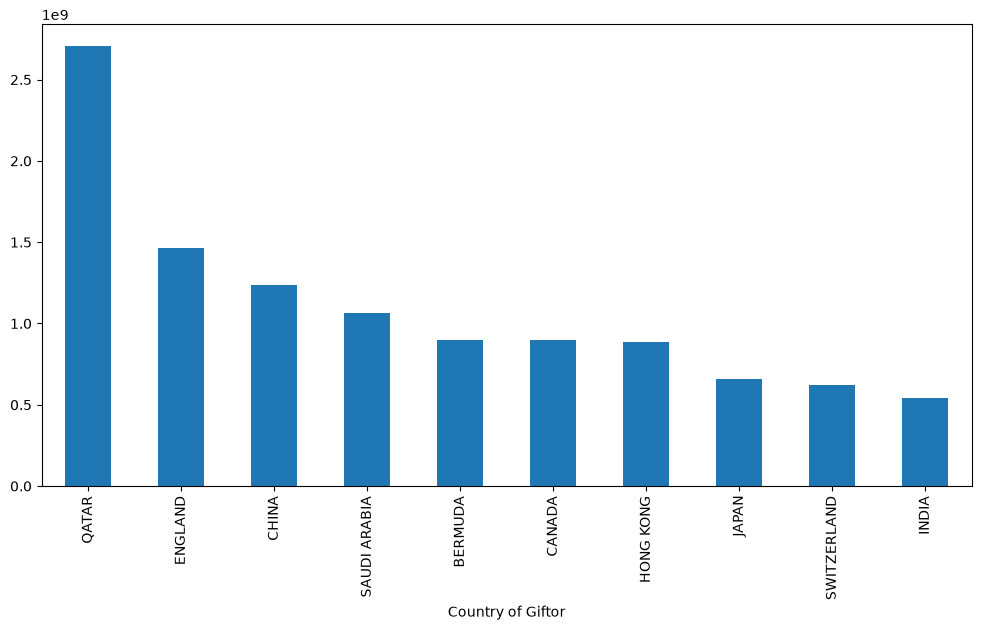

In [11]:
df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(10).plot(kind='bar', figsize=(12,6))

Qatar gives the most money in total.

<div class="alert alert-block alert-warning">
<b>Question 2:</b>  Which country initiates the most gifts, by count?
</div>


<Axes: xlabel='Country of Giftor'>

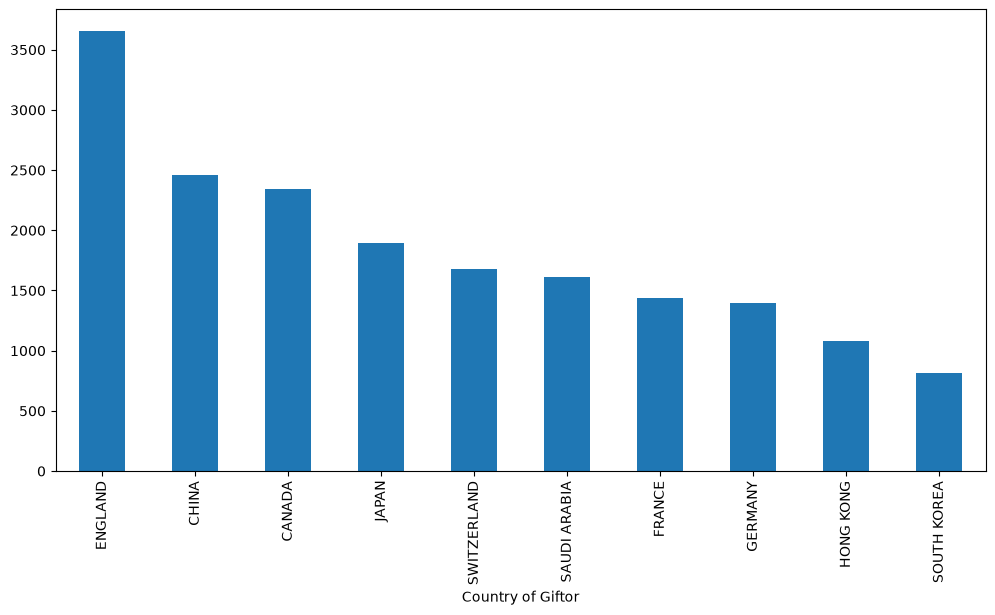

In [8]:
df.groupby('Country of Giftor')['Foreign Gift Amount'].count().sort_values(ascending=False).head(10).plot(kind='bar', figsize=(12,6))

England initiates the most gifts by count.

<div class="alert alert-block alert-warning">
<b>Question 3:</b>  Which country gives the largest gifts, on average?
</div>

<Axes: xlabel='Country of Giftor'>

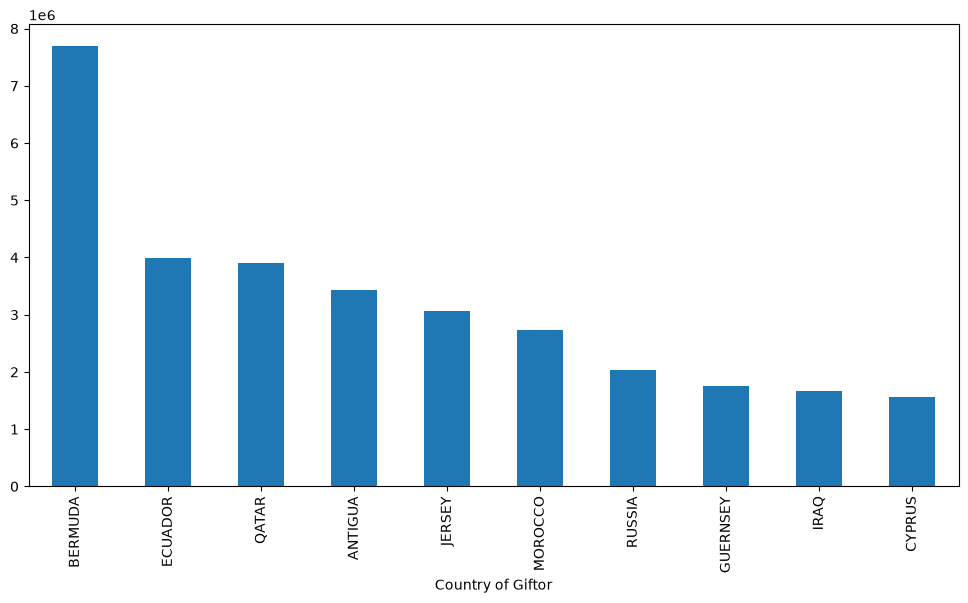

In [10]:
df.groupby('Country of Giftor')['Foreign Gift Amount'].mean().sort_values(ascending=False).head(10).plot(kind='bar', figsize=(12,6))

Bermuda gives the largest gifts on average.

## Ordering by institution

<div class="alert alert-block alert-warning">
<b>Question 4:</b>  Which institution receive the most money, in total?
</div>

<div class="alert alert-block alert-warning">
<b>Question 5:</b>  Which institution receive the greatest number of gifts, by count?
</div>

Build a plot of the top 20 institutions by the amount or number of gifts they have received using either seaborn or plotly. 

Carnagie Mellon University recieves the most gfts by amount and the University of California, Los Angelas recieves the most gifts by count.

<Axes: xlabel='Institution Name'>

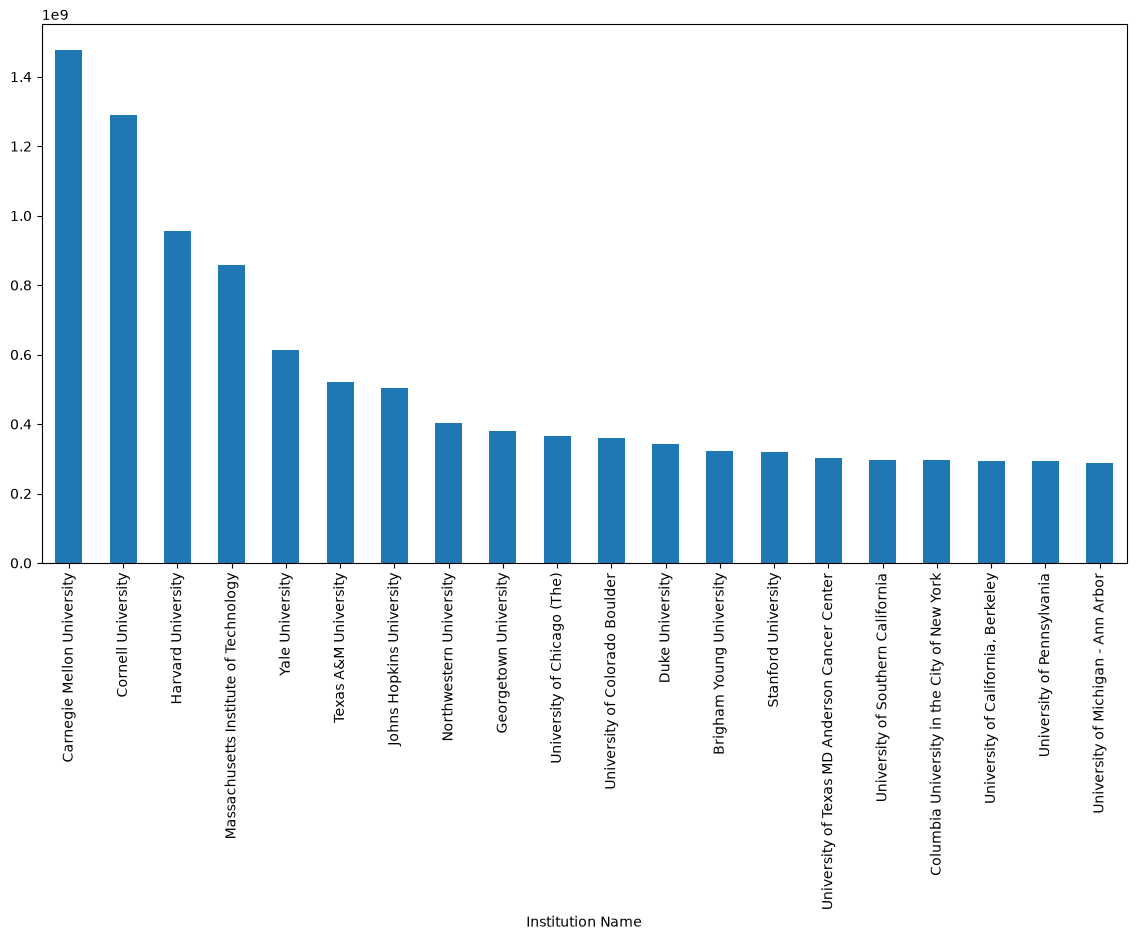

In [12]:
df.groupby('Institution Name')['Foreign Gift Amount'] \
  .sum() \
  .sort_values(ascending=False) \
  .head(20) \
  .plot(kind='bar', figsize=(14,7))

<Axes: xlabel='Institution Name'>

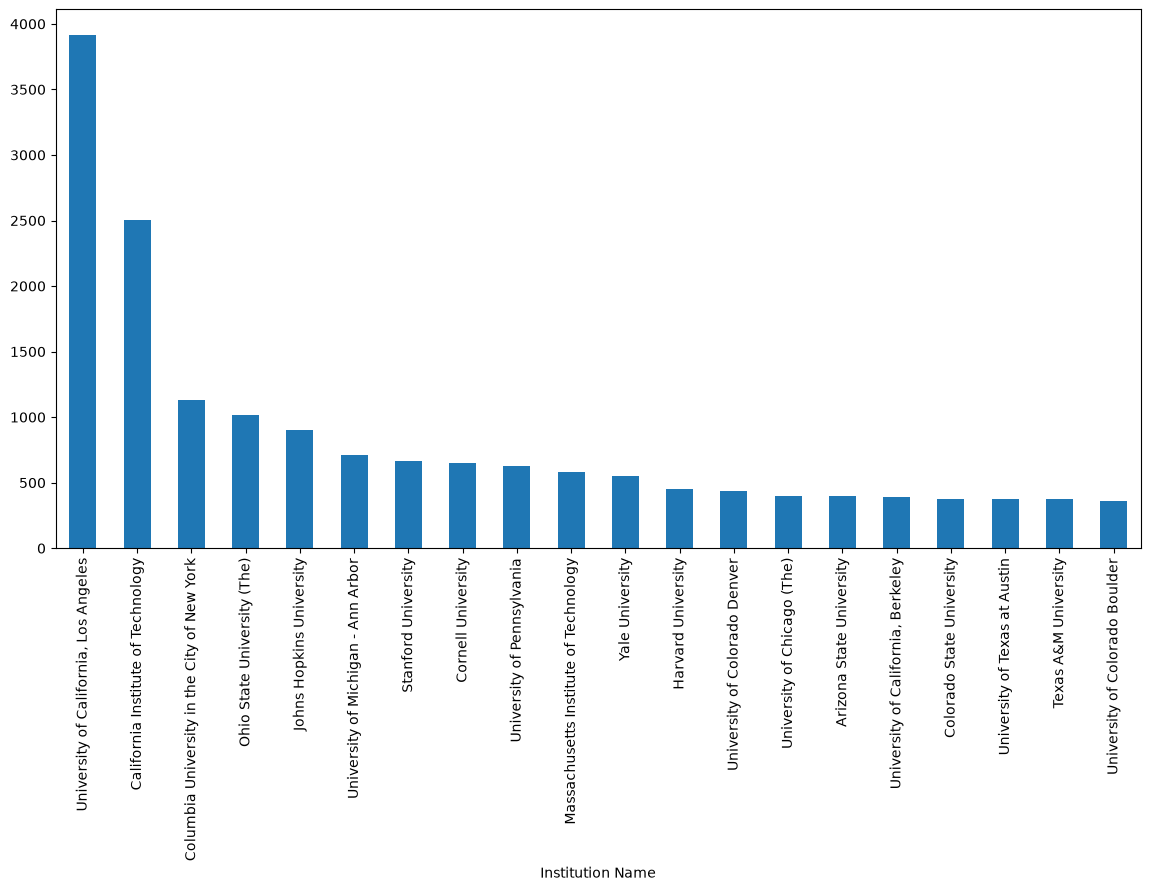

In [13]:
df.groupby('Institution Name')['Foreign Gift Amount'] \
  .count() \
  .sort_values(ascending=False) \
  .head(20) \
  .plot(kind='bar', figsize=(14,7))

## Comparing summary statistics

<div class="alert alert-block alert-warning">
<b>Question 6:</b>  What is the average amount each university receives? Median amount? If they are different, why?
</div>

Plot a histogram of the amounts received by each university, and then label the median and the mean as vertical lines.


In [17]:
university_totals = (
    df.groupby('Institution Name')['Foreign Gift Amount']
      .sum()
)

print(f"Mean amount received per university: ${university_totals.mean():,.2f}")
print(f"Median amount received per university: ${university_totals.median():,.2f}")

Mean amount received per university: $52,202,878.97
Median amount received per university: $6,486,791.50


The mean amount is $52,202,878 while the median is $6,486,791. They are so much dfferent because the data is skewed right, meaning there are universities getting larger donations which pulls the average up, but it has little effect on the median. One institution that gets much more money pulls the average up much more than having any impact on the median which is the middle of the schools lined up numerically.

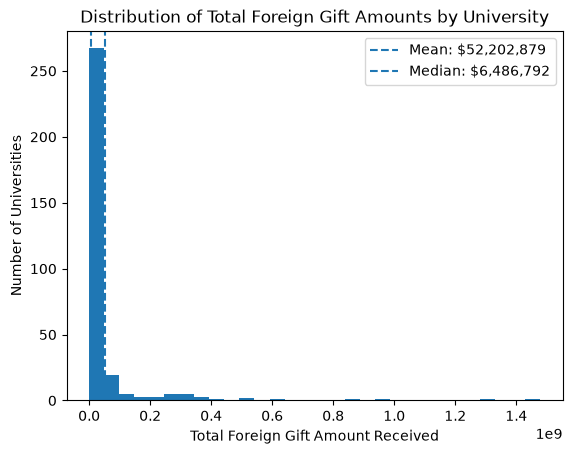

In [19]:
plt.hist(university_totals, bins=30)


plt.axvline(mean_amount, linestyle='--', label=f'Mean: ${mean_amount:,.0f}')
plt.axvline(median_amount, linestyle='--', label=f'Median: ${median_amount:,.0f}')

plt.xlabel("Total Foreign Gift Amount Received")
plt.ylabel("Number of Universities")
plt.title("Distribution of Total Foreign Gift Amounts by University")

plt.legend()
plt.show()

## Relationship between variables: 
<div class="alert alert-block alert-warning">
<b>Question 7:</b>  What is the largest flow of a single country to a single institution?
</div>

### Cross-tabulation
First, use `pd.crosstab` to look at the relationship between outcoming gifts from countries and incoming gifts to institutions. 

In [21]:
df.groupby(['Country of Giftor', 'Institution Name'])['Foreign Gift Amount'].sum().reset_index().sort_values('Foreign Gift Amount', ascending=False)

,Country of Giftor,Institution Name,Foreign Gift Amount
1865,QATAR,Cornell University,1018473315
159,BERMUDA,Carnegie Mellon University,750000000
1884,QATAR,Texas A&M University,504099350
1864,QATAR,Carnegie Mellon University,425410702
1872,QATAR,Georgetown University,327128310
...,...,...,...
2568,TURKEY,"University of California, Merced",10
2641,UNITED NATIONS,Westminster Theological Seminary,10
2552,TRINIDAD,Westminster Theological Seminary,10
788,ERITREA,"University of California, Los Angeles",3


In [24]:
flow_table = pd.crosstab(
    df['Country of Giftor'],
    df['Institution Name'],
    values=df['Foreign Gift Amount'],
    aggfunc='sum'
)
largest = (
    flow_table
    .stack()
    .sort_values(ascending=False)
    .head(1)
)

largest

Country of Giftor  Institution Name  
QATAR              Cornell University    1.018473e+09
dtype: float64

### Flow of information using alluvial plots

To better visualize which countries money is flowing from and which institutions it is flowing into, we can use an alluvial diagram. There is a built-in version in plotly that we'll use.

In [2]:
import plotly.graph_objects as go

# giftor = 'Giftor Name'
# recipi = 'Institution Name'
# flor = 'Foreign Gift Amount'

giftor = 'Giftor Name'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 20

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()



<div class="alert alert-block alert-warning">
<b>Question 8:</b>  Which are the top giftors to US academic institutions?
</div>


In [20]:
df.groupby('Giftor Name')['Foreign Gift Amount'].agg(Total_Amount='sum', Gift_Count='count').sort_values('Total_Amount', ascending=False).head(10)


,Total_Amount,Gift_Count
Giftor Name,,
Qatar Foundation,1166503744,261
Qatar Foundation/Qatar National Res,796197000,10
Qatar Foundation for Education,373945215,6
Anonymous,338793629,262
Saudi Arabian Cultural Mission,275221475,480
HCL,190000000,5
Church of Jesus Christ of LDS,185203715,7
Emirates Institute for Advanced Sc,170641244,24
QIC,148355497,2
